In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import gseapy as gp
import os
import pickle

import subcluster_funcs as funcs
sc._settings.settings._vector_friendly=True

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
post_subclustering_dir = "../post_subcluster_annotation/"
os.makedirs(post_subclustering_dir, exist_ok=True)

In [3]:
cell_type = "LEC"

In [4]:
adata = sc.read_h5ad("../post_subclustering/" + cell_type  + ".h5ad")

<Axes: xlabel='leiden', ylabel='sil_score'>

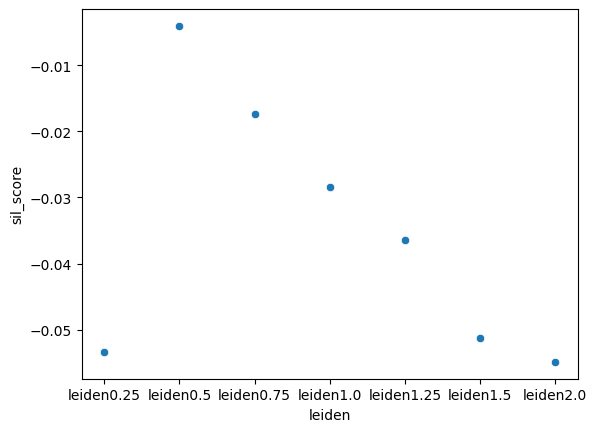

In [5]:
funcs.silhouette(adata, cell_type = cell_type)

### Leiden 0.25

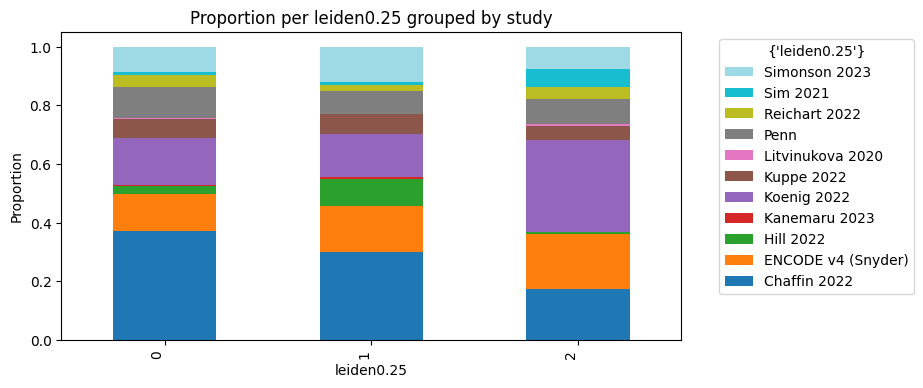

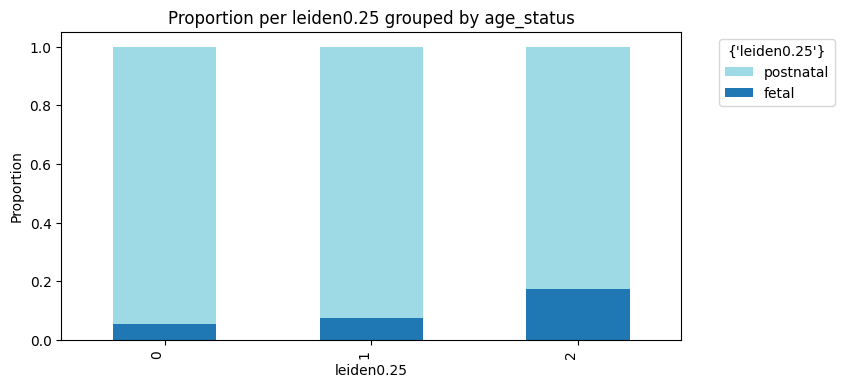

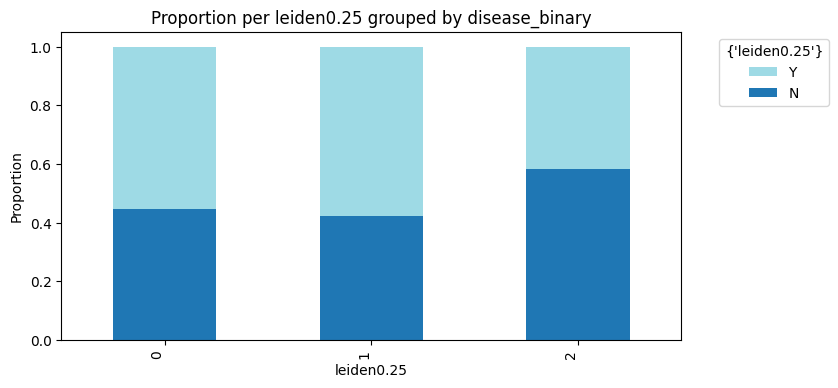

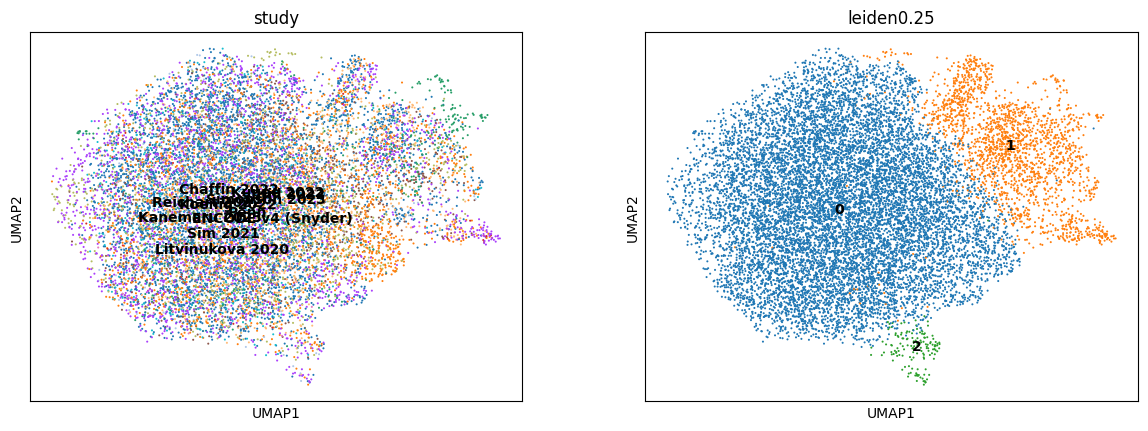

/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:459: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:459: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean

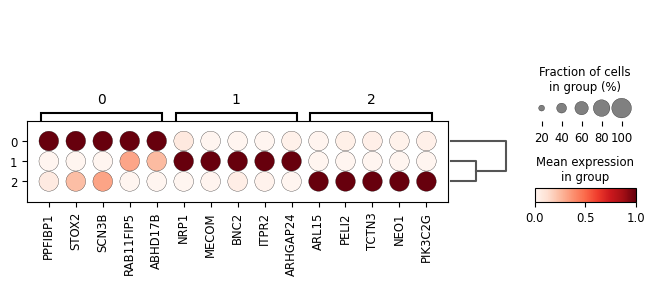

Counter({'0': 11571, '1': 2008, '2': 144})


['leiden0.25',
 AnnData object with n_obs × n_vars = 13723 × 16115
     obs: 'age', 'donor_id', 'sex', 'region', 'cell_type', 'disease', 'consistent_cell_type', 'study', 'technology', 'cell_or_nuclei', 'barcode', 'sample_id', 'age_status', 'tech_plus_study', 'disease_binary', 'decade', 'age_group', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'scvi_cell_type', 'redo_leiden_0.5', 'UMAP1', 'UMAP2', 'v2_scvi_cell_type', 'final_cell_type', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'leiden1.75', 'leiden2.0'
     var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'leiden1.75', 'leiden2.0', 'neighbors', 'pca', 'rank_genes_groupsleiden0.25', 'rank_genes_groupsleiden0.5', 'rank_genes_groupsleiden0.75', 'rank_genes_groupsleiden1.0', 'rank_genes_groupsleiden1.25', 

In [6]:
funcs.specify_leiden_subclustering(adata=adata, leiden="leiden0.25")

- Cluster 0 are capillary-associated/initial LECs
- Cluster 1 is most associated with valve-associated LECs (NRP1/GATA4/FOXC2)
- Cluster 2 is very small cluster, associated with migration (ARHGAP10/RADIL/PARD3), most similar to capillary associated

In [7]:
sc.get.rank_genes_groups_df(adata, group="1").head(40)['names']

0         NRP1
1        MECOM
2         BNC2
3        ITPR2
4     ARHGAP24
5         FGD4
6        PTPRG
7        GATA4
8         LGI3
9        DACH1
10     NOSTRIN
11     SLC17A2
12        ZEB2
13       ITPR1
14     PCDH11X
15       SMAD6
16     EPB41L3
17     SPARCL1
18        PBX1
19        XKR4
20        DKK2
21      DENND3
22       PTPRJ
23        XAF1
24     COL15A1
25        EPS8
26        EGFR
27       GTDC1
28       EPAS1
29        SCD5
30       HIPK2
31       LPAR1
32       CYTH1
33      ENTPD1
34    SLC16A12
35     RAPGEF1
36      MAP3K5
37       APBB2
38        GNG2
39       PPM1H
Name: names, dtype: object

In [8]:
adata.obs['subcluster'] = adata.obs['leiden0.25'].map(
    {"0": "Capillary",
     "1": "Valvular",
     "2": "Capillary"
    }
)

subcluster_order = ["Capillary", "Valvular"]

adata.obs['subcluster'] = pd.Categorical(
    adata.obs['subcluster'], categories=subcluster_order, ordered=True
)

subcluster_colors = {
    "Capillary": "#1f77b4",     # blue
    "Valvular": "#ff7f0e",  # orange
}

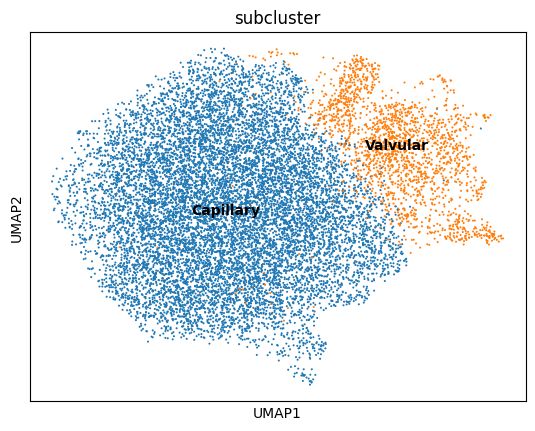

In [9]:
with plt.rc_context(): 
    sc.pl.umap(adata, color = ['subcluster'], legend_loc = "on data", palette = subcluster_colors, show=False)
    plt.savefig("LEC_subclustered.pdf", bbox_inches="tight")

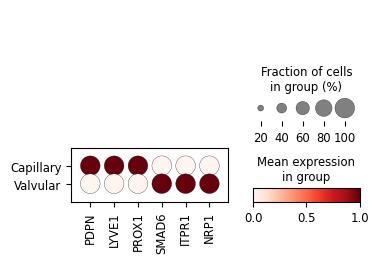

In [10]:
with plt.rc_context(): 
    sc.pl.dotplot(adata, var_names = ["PDPN", "LYVE1", "PROX1",
                                     "SMAD6", "ITPR1", "NRP1"], 
              groupby = "subcluster", show=False, standard_scale='var', layer="scvi_normalized")
    plt.savefig("LEC_subclustered_dotplot.pdf", bbox_inches="tight")